In [1]:
# %%
import torch
import numpy as np
import normflows as nf
from tqdm import tqdm
import pandas as pd

# seed = 0
# torch.manual_seed(seed)
# np.random.seed(seed)
# torch.no_grad()

import sys
import os
c_directory = os.getcwd()
sys.path.append(os.path.join(c_directory, 'FCYeast2'))

from matplotlib import pyplot as plt
import FCYeast_extrinsic_simulator
import architecture

enable_cuda = True
CUDA_LAUNCH_BLOCKING=1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


/home/pessoa/Codes/SBI-Final/FC-inference/Oblation/FCYeast_extrinsic_simulator.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autofluo.load_state_dict(torch.load('../R

In [2]:
g3 = np.loadtxt('../Real/FCYeast2_MCMC/mcmc_real_results_116224datapoints.csv')[-100000:,:]
map_index = np.argmax(g3[:,-1])
best_param = torch.tensor(g3[map_index]).float().to(device)
gt_high, gt_low = FCYeast_extrinsic_simulator.transform_to_arbitrary(best_param).cpu().numpy()


gt_sets = {"high": gt_high, "low": gt_low}


In [3]:

seed = 0


lem_high = np.loadtxt(f'oblation_mcmc_results/mcmc_results_high_{seed}_True.csv')
lem_low = np.loadtxt(f'oblation_mcmc_results/mcmc_results_low_{seed}_True.csv')
dv_high = pd.read_csv(f'oblation_simulations/non_hereditary_sim_high_seed{seed}.csv')
dv_low  = pd.read_csv(f'oblation_simulations/non_hereditary_sim_low_seed{seed}.csv')

data_high_stress = np.array(dv_high['lI'].dropna().values)
data_low_stress = np.array(dv_low['lI'].dropna().values)




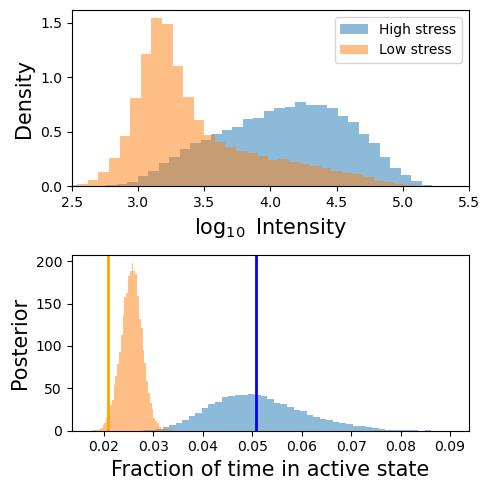

In [4]:


fig, axs = plt.subplots(2, 1, figsize=(5, 5))

# === High stress ===
t_active   = np.exp(lem_high[:, 1])
t_inactive = np.exp(lem_high[:, 2])
frac_active = t_active / (t_active + t_inactive)

axs[1].hist(frac_active, bins=50, density=True,alpha=.5)
gt_frac_active = np.exp(gt_high[1]) / (np.exp(gt_high[1]) + np.exp(gt_high[2]))
axs[1].axvline(gt_frac_active, color='blue', lw=2)


# === Low stress ===
t_active   = np.exp(lem_low[:, 1])
t_inactive = np.exp(lem_low[:, 2])
frac_active = t_active / (t_active + t_inactive)

axs[1].hist(frac_active, bins=50, density=True,alpha=.5)
gt_frac_active = np.exp(gt_low[1]) / (np.exp(gt_low[1]) + np.exp(gt_low[2]))
axs[1].axvline(gt_frac_active, color='orange', lw=2)

axs[1].set_xlabel('Fraction of time in active state',fontsize=15)
axs[1].set_ylabel("Posterior",fontsize=15)

l10 = np.log(10)
axs[0].hist(data_high_stress/l10, bins=50, density=True, alpha=.5, label='High stress')
axs[0].hist(data_low_stress/l10, bins=50, density=True, alpha=.5, label='Low stress')
axs[0].legend()
axs[0].set_xlabel(r'$\log_{10}$ Intensity',fontsize=15)
axs[0].set_ylabel("Density",fontsize=15)

axs[0].set_xlim(2.5,5.5)
plt.tight_layout()
plt.savefig('Intensity_fraction.png',dpi=500)


plt.show()



In [5]:
betas_high_stress = np.array(dv_high['betas'].dropna().values)
betas_low_stress = np.array(dv_low['betas'].dropna().values)


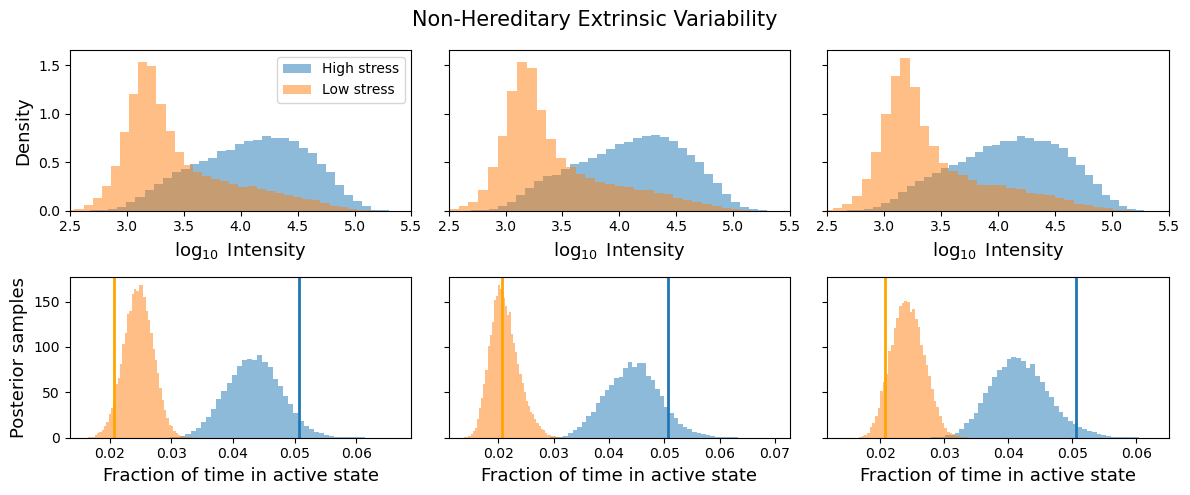

In [6]:
seeds = [0, 1, 2]

fig, axs = plt.subplots(2, 3, figsize=(12, 5), sharey='row')

l10 = np.log(10)

for col, seed in enumerate(seeds):

    # --- Load data ---
    lem_high = np.loadtxt(f'oblation_mcmc_results/mcmc_results_high_{seed}_False.csv')
    lem_low  = np.loadtxt(f'oblation_mcmc_results/mcmc_results_low_{seed}_False.csv')

    dv_high = pd.read_csv(f'oblation_simulations/non_hereditary_sim_high_seed{seed}.csv')
    dv_low  = pd.read_csv(f'oblation_simulations/non_hereditary_sim_low_seed{seed}.csv')

    data_high_stress = dv_high['lI'].dropna().values
    data_low_stress  = dv_low['lI'].dropna().values

    ax_top = axs[0, col]
    ax_bot = axs[1, col]

    # ======================
    # Row 1: Posterior fraction active
    # ======================

    # High stress
    t_active   = np.exp(lem_high[:, 1])
    t_inactive = np.exp(lem_high[:, 2])
    frac_active = t_active / (t_active + t_inactive)

    ax_bot.hist(frac_active, bins=50, density=True, alpha=.5)
    gt_frac_active = np.exp(gt_high[1]) / (np.exp(gt_high[1]) + np.exp(gt_high[2]))
    ax_bot.axvline(gt_frac_active, lw=2)

    # Low stress
    t_active   = np.exp(lem_low[:, 1])
    t_inactive = np.exp(lem_low[:, 2])
    frac_active = t_active / (t_active + t_inactive)

    ax_bot.hist(frac_active, bins=50, density=True, alpha=.5)
    gt_frac_active = np.exp(gt_low[1]) / (np.exp(gt_low[1]) + np.exp(gt_low[2]))
    ax_bot.axvline(gt_frac_active, lw=2,color='orange')



    if col == 0:
        ax_bot.set_ylabel("Posterior samples", fontsize=13)

    ax_bot.set_xlabel('Fraction of time in active state',fontsize=13)

    # ======================
    # Row 0: Intensity histograms
    # ======================

    ax_top.hist(data_high_stress / l10, bins=50, density=True, alpha=.5, label='High stress')
    ax_top.hist(data_low_stress  / l10, bins=50, density=True, alpha=.5, label='Low stress')

    if col == 0:
        ax_top.set_ylabel("Density", fontsize=13)
        ax_top.legend()

    ax_top.set_xlabel(r'$\log_{10}$ Intensity', fontsize=13)
    ax_top.set_xlim(2.5, 5.5)
fig.suptitle("Non-Hereditary Extrinsic Variability",fontsize=15)

plt.tight_layout()
plt.savefig('Intensity_fraction_3seeds_nonhereditary.png', dpi=500)
plt.show()


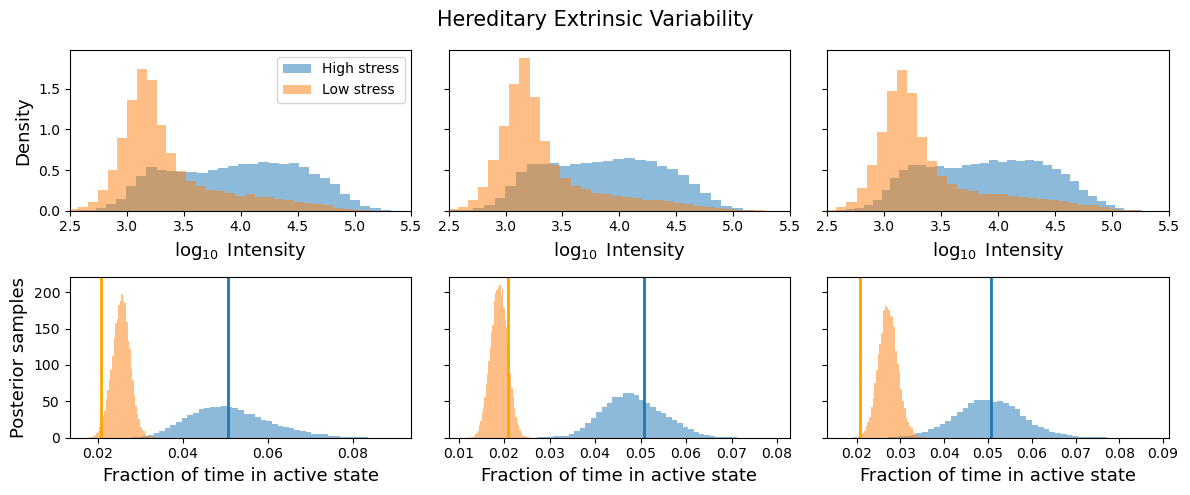

In [7]:

seeds = [0, 1, 2]

fig, axs = plt.subplots(2, 3, figsize=(12, 5), sharey='row')

l10 = np.log(10)

for col, seed in enumerate(seeds):

    # --- Load data ---
    lem_high = np.loadtxt(f'oblation_mcmc_results/mcmc_results_high_{seed}_True.csv')
    lem_low  = np.loadtxt(f'oblation_mcmc_results/mcmc_results_low_{seed}_True.csv')

    dv_high = pd.read_csv(f'oblation_simulations/sim_high_seed{seed}.csv')
    dv_low  = pd.read_csv(f'oblation_simulations/sim_low_seed{seed}.csv')

    data_high_stress = dv_high['lI'].dropna().values
    data_low_stress  = dv_low['lI'].dropna().values

    ax_top = axs[0, col]
    ax_bot = axs[1, col]

    # ======================
    # Row 1: Posterior fraction active
    # ======================

    # High stress
    t_active   = np.exp(lem_high[:, 1])
    t_inactive = np.exp(lem_high[:, 2])
    frac_active = t_active / (t_active + t_inactive)

    ax_bot.hist(frac_active, bins=50, density=True, alpha=.5)
    gt_frac_active = np.exp(gt_high[1]) / (np.exp(gt_high[1]) + np.exp(gt_high[2]))
    ax_bot.axvline(gt_frac_active, lw=2)

    # Low stress
    t_active   = np.exp(lem_low[:, 1])
    t_inactive = np.exp(lem_low[:, 2])
    frac_active = t_active / (t_active + t_inactive)

    ax_bot.hist(frac_active, bins=50, density=True, alpha=.5)
    gt_frac_active = np.exp(gt_low[1]) / (np.exp(gt_low[1]) + np.exp(gt_low[2]))
    ax_bot.axvline(gt_frac_active, lw=2,color='orange')



    if col == 0:
        ax_bot.set_ylabel("Posterior samples", fontsize=13)

    ax_bot.set_xlabel('Fraction of time in active state',fontsize=13)

    # ======================
    # Row 0: Intensity histograms
    # ======================

    ax_top.hist(data_high_stress / l10, bins=50, density=True, alpha=.5, label='High stress')
    ax_top.hist(data_low_stress  / l10, bins=50, density=True, alpha=.5, label='Low stress')

    if col == 0:
        ax_top.set_ylabel("Density", fontsize=13)
        ax_top.legend()

    ax_top.set_xlabel(r'$\log_{10}$ Intensity', fontsize=13)
    ax_top.set_xlim(2.5, 5.5)
fig.suptitle("Hereditary Extrinsic Variability",fontsize=15)

plt.tight_layout()
plt.savefig('Intensity_fraction_3seeds.png', dpi=500)
plt.show()
